In [10]:
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = load_iris(as_frame=True)
x = iris.data[['petal length (cm)', 'petal width (cm)']].to_numpy()
y = (iris.target == 2) 

self_clf = make_pipeline(StandardScaler(),
                         LinearSVC(C=1, random_state=42))

self_clf.fit(x, y)

,steps,"[('standardscaler', ...), ('linearsvc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001


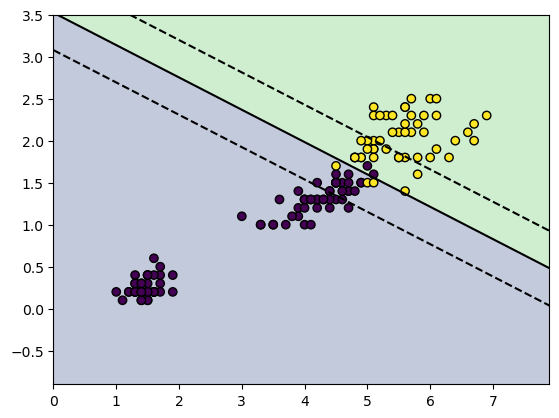

In [11]:
import numpy as np
import matplotlib.pyplot as plt

x0_min, x0_max = x[:,0].min()-1, x[:,0].max()+1
x1_min, x1_max = x[:,1].min()-1, x[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x0_min, x0_max, 500),
    np.linspace(x1_min, x1_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]

z = self_clf.predict(grid)
z = z.reshape(xx.shape)

plt.contourf(xx,yy, z, alpha=0.3)
plt.scatter(x[:,0], x[:,1], c=y, edgecolors='k')

decision = self_clf.decision_function(grid)
decision = decision.reshape(xx.shape)

plt.contour(
    xx, yy, decision, levels=[-1,0,1],
    linestyles=['--','-','--'], colors='k'
)

plt.show()

In [4]:
from sklearn.datasets import make_moons
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import LinearSVC

x, y = make_moons(n_samples=100, noise=0.15, random_state=42)

ploynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearSVC(C=10, max_iter=10_100, random_state=42)
)
ploynomial_svm_clf.fit(x,y)

,steps,"[('polynomialfeatures', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


              precision    recall  f1-score   support

       False       0.96      0.97      0.97       100
        True       0.94      0.92      0.93        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150

              precision    recall  f1-score   support

       False       1.00      0.94      0.97       100
        True       0.89      1.00      0.94        50

    accuracy                           0.96       150
   macro avg       0.95      0.97      0.96       150
weighted avg       0.96      0.96      0.96       150



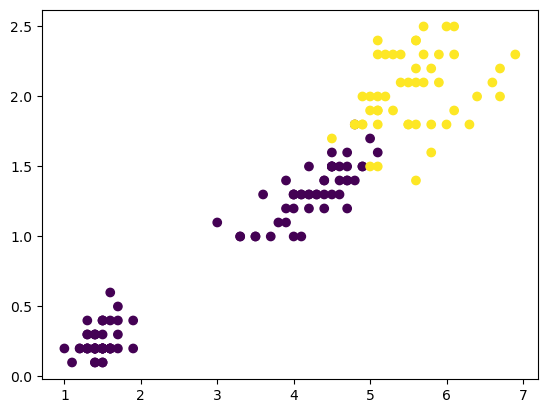

In [12]:
# 분류모델
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

plt.scatter(x[:,0], x[:,1], c=y)

models = {'lr':LogisticRegression(random_state=42), 'sgd':SGDClassifier(random_state=42)}

for label, model in models.items():
    # 파이프 라인
    pipeline = Pipeline([
        ('scaler',StandardScaler()),
        (label, model)
    ])

    pipeline.fit(x,y)
    predict = pipeline.predict(x)
    print(classification_report(y, predict))


In [ ]:
# svc 적용
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('svc',SVC(kernel='poly', degree=3, C=5, coef0=1))
])

pipeline.fit(x,y)
predict = pipeline.predict(x)
print(classification_report(y, predict))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        50
           1       0.98      0.98      0.98        50

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



In [6]:
# 와인품질 분류

from sklearn.datasets import load_wine
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

data = load_wine(as_frame=True)

df = data.frame

x = df.drop('target', axis=1)
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

lin_model = make_pipeline(
    StandardScaler(),
    LinearSVC(C=1, random_state=42)
)
lin_model.fit(x_train,y_train)

svc_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf')
)
svc_model.fit(x_train, y_train)

,steps,"[('standardscaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [7]:
from sklearn.metrics import classification_report

lin_predict = lin_model.predict(x_test)
print(classification_report(y_test, lin_predict))

svc_predict = svc_model.predict(x_test)
print(classification_report(y_test, svc_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [8]:
from sklearn.model_selection import cross_val_score

lin_scores = cross_val_score(lin_model, x, y, cv=5)
svc_scores = cross_val_score(svc_model, x, y, cv=5)

print(lin_scores, svc_scores)
print(lin_scores.mean(), svc_scores.mean())

[0.97222222 0.97222222 0.97222222 0.97142857 1.        ] [1.         0.97222222 0.94444444 1.         1.        ]
0.9776190476190475 0.9833333333333334


In [16]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
x = iris.data[['petal length (cm)', 'petal width (cm)']]
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(x, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


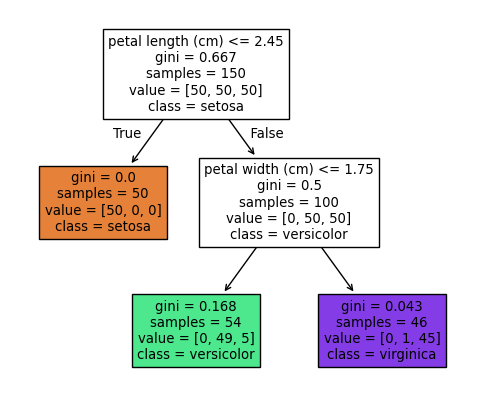

In [17]:
# 결정 트리
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plot_tree(tree_clf, feature_names=x.columns, class_names=iris.target_names, filled=True)
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(x_train, y_train)
y_pred = tree_clf.predict(x_test)
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [5]:
# 지니계수 : 데이터의 순도 측정하는 지표
# 순도가 높다 : 집단안에 같은 종류의 데이터만 모여있다 (지니계수 낮음)
# 불순도가 높다 : 여러 종류의 데이터가 마구 섞여있다 (지니계수 높음)
# 데이터를 분할할떄마다 지니계수가 낮아지는 방향으로 가지를 뻗는다

In [13]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
x = iris.data.copy()
y = iris.target

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(x, y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


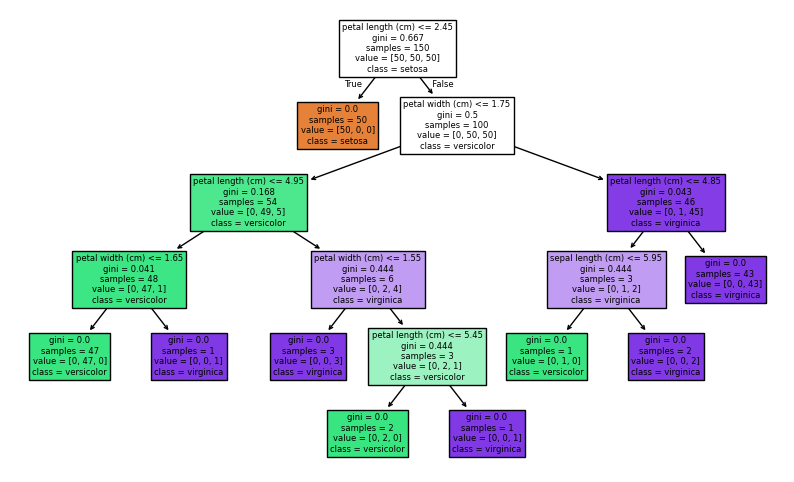

In [ ]:
# 결정 트리 -> max_depth 설정 안함
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_tree(tree_clf, feature_names=x.columns, class_names=iris.target_names, filled=True)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(x_train, y_train)
y_pred = tree_clf.predict(x_test)
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print(tree_clf.feature_importances_)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

[0.57829701 0.42170299]


In [ ]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42, )

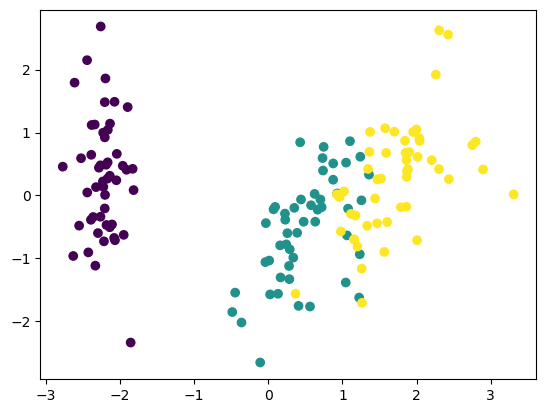

In [23]:
# pca 주성분 분석
# 데이터의 분산이 가장 큰 방향으로 축을 만들어 데이터를 투영

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

iris = load_iris(as_frame=True)
pca = PCA(n_components=2, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

x = pipeline.fit_transform(iris.data)
y = iris.target

plt.scatter(x[:,0], x[:,1], c=y)
plt.show()